In [1]:
%cd ..
%load_ext autoreload
%autoreload 2
# %load_ext nb_black
# notebook setup

from pathlib import Path
import sys

sys.path.insert(0, Path().absolute().parent.as_posix())

/Users/ruizhechao/Documents/NNforHJB


# Penalty Function Comparison

Reproduces Figure 2 from the reference paper and adds our power-transformed penalty
curves for activation power `p = 2.1`, i.e. `q = 2/(p+1) approx 0.645`.

**Curves shown**
- L1: phi(z) = z
- Log penalty phi_log,1: phi(z) = log(1+z)
- MCP (gamma=1): phi(z) = z - z^2/2 for z<1, then 1/2
- SCAD (lambda=1, a=3.7): standard SCAD
- [NEW] Power function: |z|^q, q = 2/(p+1), p = 2.1
- [NEW] Combined (log o power): phi_log,1(|z|^q) = log(1 + |z|^q)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9.5,
    'lines.linewidth': 1.8,
})

# domain
z = np.linspace(0, 3, 3000)

def safe_pow(z, exp):
    """z^exp element-wise; 0 where z=0 (handles exp < 0)."""
    return np.where(z > 0, np.power(np.where(z > 0, z, 1.0), exp), 0.0)

# --- L1 ---
phi_l1   = z
dphi_l1  = np.ones_like(z)

# --- log penalty  phi_log,1(z) = log(1+z) ---
phi_log  = np.log1p(z)
dphi_log = 1.0 / (1.0 + z)

# --- MCP  lambda=1, gamma=1 ---
# phi(z) = z - z^2/2  for z<1,  1/2  for z>=1
# phi'(z) = 1 - z     for z<1,  0    for z>=1
phi_mcp  = np.where(z < 1.0, z - 0.5*z**2, 0.5)
dphi_mcp = np.where(z < 1.0, 1.0 - z,      0.0)

# --- SCAD  lambda=1, a=3.7 ---
# phi(z)  = z                                       for z < 1
#         = -(z^2 - 2*a*z + 1) / (2*(a-1))          for 1 <= z < a
#         = (a+1)/2                                  for z >= a
# phi'(z) = 1                                       for z < 1
#         = (a - z) / (a - 1)                        for 1 <= z < a
#         = 0                                        for z >= a
a_scad = 3.7
phi_scad = np.where(
    z < 1.0, z,
    np.where(z < a_scad,
             -(z**2 - 2.0*a_scad*z + 1.0) / (2.0*(a_scad-1.0)),
             (a_scad+1.0)/2.0))
dphi_scad = np.where(
    z < 1.0, 1.0,
    np.where(z < a_scad, (a_scad-z)/(a_scad-1.0), 0.0))

# --- our power-transformed penalty: p=2.1, q=2/(p+1) ---
p = 2.1
q = 2.0 / (p + 1.0)   # 2/3.1 approx 0.6452
print(f"p = {p},  q = 2/(p+1) = {q:.6f}")

# (i) power function alone: |z|^q
phi_power  = safe_pow(z, q)
dphi_power = safe_pow(z, q-1) * q        # q * z^(q-1)

# (ii) combined: phi_log,1 applied to |z|^q  =>  log(1 + |z|^q)
#     d/dz = q * z^(q-1) / (1 + z^q)
zq = safe_pow(z, q)
phi_comb  = np.log1p(zq)
dphi_comb = q * safe_pow(z, q-1) / (1.0 + zq)


p = 2.1,  q = 2/(p+1) = 0.645161


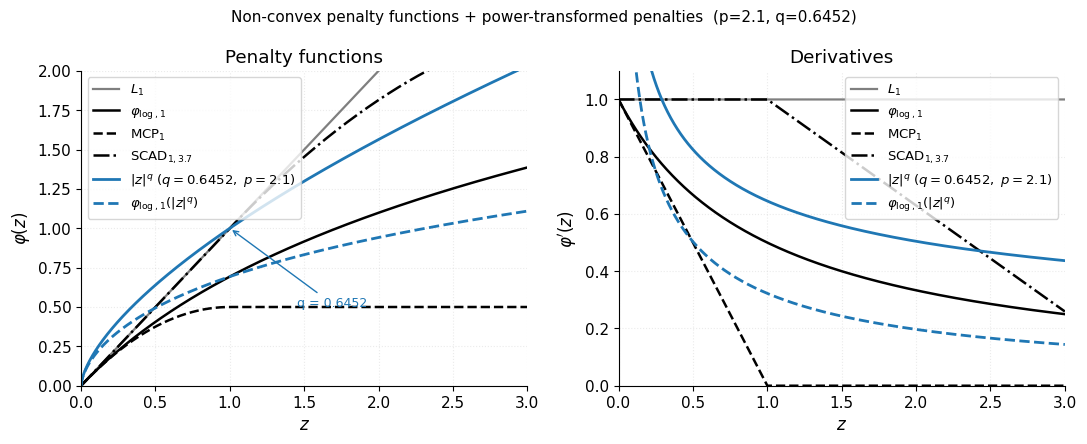

Saved penalty_comparison.pdf


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# (phi_vals, dphi_vals, color, linestyle, linewidth, label)
curves = [
    (phi_l1,    dphi_l1,    'tab:gray', '-',   1.6, r'$L_1$'),
    (phi_log,   dphi_log,   'black',    '-',   1.8, r'$\varphi_{\log,1}$'),
    (phi_mcp,   dphi_mcp,   'black',    '--',  1.8, r'$\mathrm{MCP}_1$'),
    (phi_scad,  dphi_scad,  'black',    '-.',  1.8, r'$\mathrm{SCAD}_{1,3.7}$'),
    (phi_power, dphi_power, 'tab:blue', '-',   2.0,
        r'$|z|^{q}$' + f' ($q={q:.4f},\\ p={p}$)'),
    (phi_comb,  dphi_comb,  'tab:blue', '--',  2.0,
        r'$\varphi_{\log,1}(|z|^{q})$'),
]

for phi_vals, dphi_vals, color, ls, lw, label in curves:
    axes[0].plot(z, phi_vals,  color=color, linestyle=ls, linewidth=lw, label=label)
    axes[1].plot(z, dphi_vals, color=color, linestyle=ls, linewidth=lw, label=label)

idx1 = np.searchsorted(z, 1.0)
axes[0].annotate(f'q = {q:.4f}',
    xy=(1.0, phi_power[idx1]), xytext=(1.45, 0.50),
    fontsize=9, color='tab:blue',
    arrowprops=dict(arrowstyle='->', color='tab:blue', lw=1.0))

for ax, ylabel, title in zip(
    axes,
    [r'$\varphi(z)$', r"$\varphi'(z)$"],
    ['Penalty functions', 'Derivatives']):
    ax.set_xlabel(r'$z$')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 3)
    ax.set_ylim(bottom=0)
    ax.set_title(title)
    ax.legend(loc='upper left' if ax is axes[0] else 'upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.25, linestyle=':')

axes[0].set_ylim(0, 2.0)
axes[1].set_ylim(0, 1.1)

fig.suptitle(
    f'Non-convex penalty functions + power-transformed penalties  (p={p}, q={q:.4f})',
    fontsize=11)
fig.tight_layout()
plt.savefig('penalty_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved penalty_comparison.pdf')


In [4]:
# Sanity check: tabulate values at selected z
check_z = [0.0, 0.5, 1.0, 2.0, 3.0]
cols  = ['L1', 'log', 'MCP', 'SCAD', '|z|^q', 'log(1+|z|^q)']
data  = [phi_l1, phi_log, phi_mcp, phi_scad, phi_power, phi_comb]

header = f"{'z':>5}  " + "  ".join(f"{c:>14}" for c in cols)
print(header)
print('-' * len(header))
for z_val in check_z:
    idx = min(np.searchsorted(z, z_val), len(z)-1)
    row = f"{z_val:5.1f}  " + "  ".join(f"{arr[idx]:14.6f}" for arr in data)
    print(row)


    z              L1             log             MCP            SCAD           |z|^q    log(1+|z|^q)
-----------------------------------------------------------------------------------------------------
  0.0        0.000000        0.000000        0.000000        0.000000        0.000000        0.000000
  0.5        0.500167        0.405576        0.375083        0.500167        0.639559        0.494427
  1.0        1.000333        0.693314        0.500000        1.000333        1.000215        0.693255
  2.0        2.000667        1.098835        0.500000        1.815235        1.564251        0.941666
  3.0        3.000000        1.386294        0.500000        2.259259        2.031516        1.109063


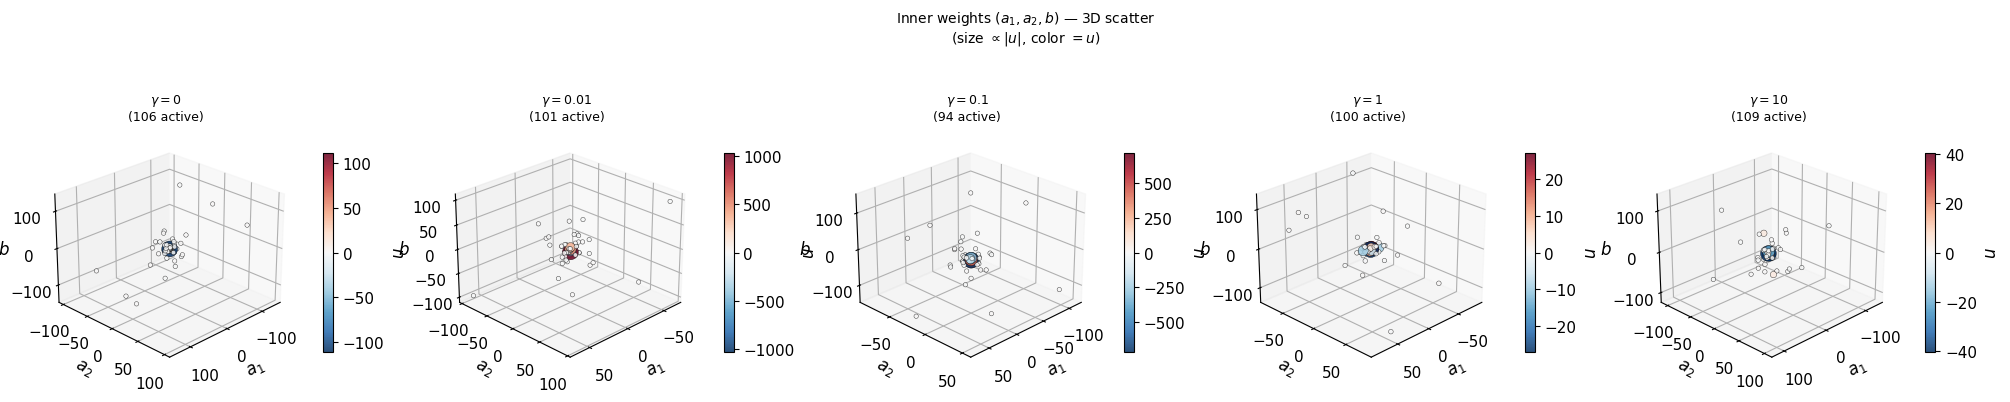

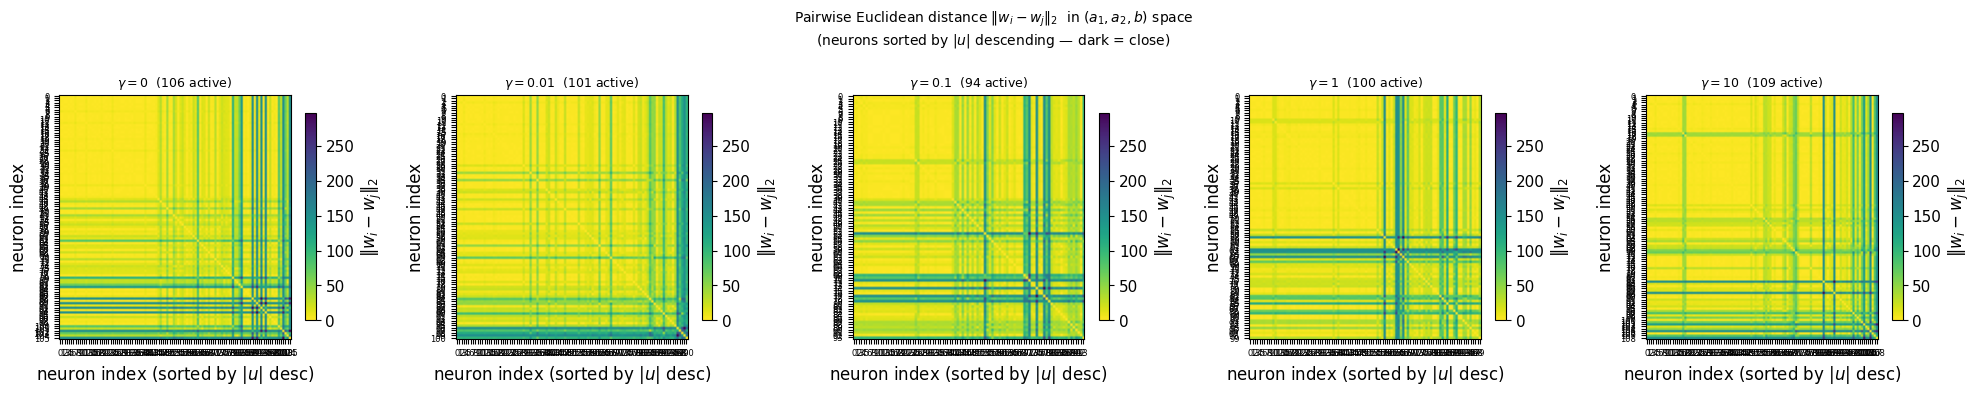

(<Figure size 2000x400 with 10 Axes>,
 array([<Axes: title={'center': '$\\gamma=0$  (106 active)'}, xlabel='neuron index (sorted by $|u|$ desc)', ylabel='neuron index'>,
        <Axes: title={'center': '$\\gamma=0.01$  (101 active)'}, xlabel='neuron index (sorted by $|u|$ desc)', ylabel='neuron index'>,
        <Axes: title={'center': '$\\gamma=0.1$  (94 active)'}, xlabel='neuron index (sorted by $|u|$ desc)', ylabel='neuron index'>,
        <Axes: title={'center': '$\\gamma=1$  (100 active)'}, xlabel='neuron index (sorted by $|u|$ desc)', ylabel='neuron index'>,
        <Axes: title={'center': '$\\gamma=10$  (109 active)'}, xlabel='neuron index (sorted by $|u|$ desc)', ylabel='neuron index'>],
       dtype=object))

In [7]:
from src.metric import plot_inner_weight_3d_scatter, plot_inner_weight_pairwise_distance

plot_inner_weight_3d_scatter('models/experiment_5.pkl')
plot_inner_weight_pairwise_distance('models/experiment_5.pkl')